# 4단계: Gemma-2B full fine-tuning (논문 Octopus-3 조건)
학습 코드는 `src/train.py` 에 있다. 이 노트북은 GitHub 에서 코드를 받아 **실행만** 한다.
(코드를 고칠 땐 랩탑에서 고치고 push → 여기서 `git pull`)

- 런타임: **A100 GPU + 고용량 RAM (GPU 80GB)**. 40GB 에서는 일반 AdamW 가 메모리에 안 들어간다. 🔑 Secrets에 `HF_TOKEN` 등록 (`google/gemma-2b` 라이선스 동의한 계정)
- 결과는 Google Drive 의 `MyDrive/octopus_v2/runs/` 에 저장
- 학습 설정: 논문 3.4절 (AdamW, lr 5e-5, warm-up 10, linear, 3 epochs) + batch 16 (논문에 없는 추가)

## 준비 (그냥 실행)

In [1]:
# 랩탑에서 확인한 버전으로 고정 (최신 5.x 는 API 가 바뀌어 에러가 난다)
# 처음 설치한 뒤에는 '런타임 > 세션 다시 시작' 후 이 칸부터 다시 실행
!pip -q install transformers==4.56.2 accelerate bitsandbytes
from huggingface_hub import login
from google.colab import userdata, drive

login(userdata.get("HF_TOKEN"))
drive.mount("/content/drive")

import os
REPO = "/content/octopus_v2_reproduce"
if not os.path.exists(REPO):
    !git clone https://github.com/nahcub/octopus_v2_reproduce.git {REPO}
%cd {REPO}
!git pull
!git log --oneline -1

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/octopus_v2_reproduce
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.32 KiB | 676.00 KiB/s, done.
From https://github.com/nahcub/octopus_v2_reproduce
   4c210fe..4af5dac  main       -> origin/main
Updating 4c210fe..4af5dac
Fast-forward
 README.md                | 2 ++
 notebooks/04_train.ipynb | 9 ++++++---
 requirements.txt         | 2 +-
 3 files changed, 9 insertions(+), 4 deletions(-)
4af5dac (HEAD -> main, origin/main, origin/HEAD) 4단계 랩탑에서 할건 다함. 코랩 돌리는 중.


In [5]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
import transformers; print("transformers", transformers.__version__)

name, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB
transformers 5.18.0


---
## 4-3. 학습 전 점검
모델을 올리고, 단어 뜻 칸을 늘리고, 학습 전 loss 를 본다.

**예측**: 칸은 몇 → 몇? `<nexa_*>` 자리 loss 는 나머지 정답 자리보다 높을까 낮을까?
> (여기에 예측)

확인할 것
- `[모델] 단어 뜻 칸 256000 → 256022`
- `<nexa_*>` 자리 loss 가 나머지보다 높아야 정상 (아직 뜻이 없는 새 단어)
- `[GPU] 모델만 올렸을 때 ~10 GiB` (2.5B × fp32 4바이트)

In [ ]:
!python -m src.train --check-only

---
## 4-4. 짧게 시험 학습 (30 step)
loss 가 내려가는지, 메모리가 버티는지만 본다. 저장은 `/content` (Drive 아님).

80GB 에서는 옵션 없이 된다 (최대 67.3 GiB). **메모리 부족(CUDA out of memory)이 나면** 위에서부터 하나씩 추가
(2번 8-bit AdamW 는 논문의 AdamW 와 달라지므로 쓰면 README 에 기록)
1. `--batch-size 4 --grad-accum 4` : 한 번에 4개씩 4번 모아서 갱신 → 실제 batch 는 그대로 16
2. `--optim adamw_bnb_8bit` : AdamW 가 기억하는 값을 8bit 로 (약 20GB → 5GB)
3. `--gradient-checkpointing` : 중간 계산을 버렸다 다시 계산 (느려짐)

쓴 옵션은 아래 본 학습에도 똑같이 붙이고, README 에 기록한다.

In [6]:
EXTRA = ""   # 예: "--batch-size 4 --grad-accum 4 --optim adamw_bnb_8bit"
!python -m src.train --max-steps 30 --output-dir /content/runs/try {EXTRA}

2026-10-04 09:36:35.921731: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-04 09:36:35.996610: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
tokenizer.model: 100% 4.24M/4.24M [00:01<00:00, 3.76MB/s]
model.safetensors.index.json: 13.5kB [00:00, 41.2MB/s]
Fetching 2 files:   0% 0/2 [00:00<?, ?it/s]
model-00001-of-00002.safetensors:   0% 0.00/4.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0% 0.00/67.1M [00:00<?, ?B/s]
model-00001-of-00002.safetensors:   5% 268M/4.95G [00:01<00:26, 178MB/s]
model-00001

---
## 4-5. 본 학습 (3 epoch)
4,000개 ÷ 16 = 250 step × 3 = 750 step. 끝나면 모델·토크나이저·loss 기록이 Drive 에 저장된다.

In [7]:
RUN_DIR = "/content/drive/MyDrive/octopus_v2/runs/full"
!python -m src.train --output-dir {RUN_DIR} {EXTRA}

2026-10-04 09:38:36.304030: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-04 09:38:36.380479: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading checkpoint shards: 100% 2/2 [00:01<00:00,  1.22it/s]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
[모델] 단어 뜻 칸 256000 → 256022 | 사전 256022 | 파라미터 2.51B
[데이터] 

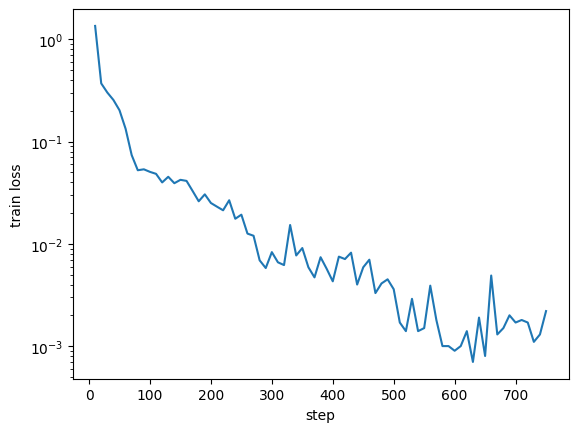

In [8]:
# loss 곡선
import json, matplotlib.pyplot as plt
logs = [l for l in json.load(open(f"{RUN_DIR}/log_history.json")) if "loss" in l]
plt.plot([l["step"] for l in logs], [l["loss"] for l in logs]); plt.xlabel("step"); plt.ylabel("train loss"); plt.yscale("log"); plt.show()

---
## 4-6. 저장한 모델 다시 불러서 몇 개 생성해 보기
정확도 측정은 5단계. 여기서는 모양만 본다. `<nexa_end>` 에서 멈추게 한다.
`skip_special_tokens=False` 로 decode (True 면 `<nexa_*>` 가 지워진다).

In [2]:
# 세션을 다시 시작했으면 4-5(학습)를 다시 돌리지 말고 여기부터 실행 (모델은 Drive 에 있다)
RUN_DIR = "/content/drive/MyDrive/octopus_v2/runs/full"

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from src.preprocess.prompt import build_prompt, load_jsonl
from pathlib import Path

tok = AutoTokenizer.from_pretrained(RUN_DIR)
model = AutoModelForCausalLM.from_pretrained(RUN_DIR, dtype=torch.bfloat16, device_map="cuda").eval()
stop = [tok.convert_tokens_to_ids("<nexa_end>"), tok.eos_token_id]

test = load_jsonl(Path("data/test.jsonl"))
for row in test[:3] + test[-3:]:
    ids = tok(build_prompt(row["query"]), return_tensors="pt").to("cuda")
    out = model.generate(**ids, max_new_tokens=64, do_sample=False, eos_token_id=stop)
    pred = tok.decode(out[0, ids["input_ids"].shape[1]:], skip_special_tokens=False)
    print(f"""Q: {row['query']}
   정답: {row['call']}
   예측:{pred}
""")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Q: Capture an image using front camera.
   정답: <nexa_0>('front')<nexa_end>
   예측: <nexa_0>('front')<nexa_end>

Q: Could you snap a picture of my outfit using the front-facing camera?
   정답: <nexa_0>('front')<nexa_end>
   예측: <nexa_0>('front')<nexa_end>

Q: Can you snap a photo using the back camera?
   정답: <nexa_0>('back')<nexa_end>
   예측: <nexa_0>('back')<nexa_end>

Q: Switch the oven from conventional bake to convection roast at 375.
   정답: <nexa_20>()<nexa_end>
   예측: <nexa_20>()<nexa_end>

Q: Brew me a double espresso using the smart coffee maker.
   정답: <nexa_20>()<nexa_end>
   예측: <nexa_20>()<nexa_end>

Q: Enable the ionizer function on the basement air purifier.
   정답: <nexa_20>()<nexa_end>
   예측: <nexa_20>()<nexa_end>

